In [1]:
import os
import sys
import pandas as pd
import numpy as np
import anndata as ad
import glob
import time
import gget
import scipy
import scipy.sparse as sp
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
import matplotlib.patches as mpatches
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import issparse
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
# import HAT
# from HAT import draw

#import surprise as sup

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

# local imports
#import anndata_utils as anntools

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
import matrix
import utils as ut
#import plotting as plt2
source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central

In [2]:
# Read in core incidence
path_clean = f"/scratch/indikar_root/indikar1/jduhamel/pore_c/population_mESC_100000_core.h5ad"

start_time = time.time()  # Record the start time
cdata = sc.read_h5ad(path_clean)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()

# sort the object by global bin id
sorted_indices = cdata.obs['bin'].argsort()
cdata = cdata[sorted_indices, :] 

Time taken to read the file: 5.63 seconds
Memory usage: current 0.69 GB, difference +0.69 GB


In [3]:
cdata.obs.head()

,bin_index,bin_start,bin_end,bin,chrom,chrom_bin,degree,genes,n_genes,ATACSeq_1,...,RNA_3,RNA_4,RNA_5,RNA_6,PolII,degree_outlier,global_hge_logexp_unweighted,node_curvature,normalized_node_curvature,abs_normalized_node_curvature
bin_name,,,,,,,,,,,,,,,,,,,,,
chr1:84,407,84000000,85000000,84,1,84,4238,Rpl19-ps1;Fbxo36;Pid1;Gm29284;Slc16a14;Trip12;...,14,0.703279,...,0.314251,0.098778,1.211114,0.274199,0.579365,False,0.000440,-13492430,-3670.410773,3670.410773
chr1:171,1330,171000000,172000000,171,1,171,4001,Pfdn2;Cd244a;Gm37756;Slamf1;Slamf6;Ufc1;Dedd;G...,54,0.821434,...,0.320072,0.223690,0.982882,0.278913,1.422092,False,0.000437,-12256088,-3498.740508,3498.740508
chr2:5,2533,5000000,6000000,201,2,5,3913,Nudt5;Sec61a2;Mcm10;Ccdc3;Upf2;Cdc123;Gm23118;...,14,0.798978,...,0.203288,1.073346,0.392122,0.154685,1.001035,False,0.000436,-11547138,-3398.216009,3398.216009
chr2:20,2251,20000000,21000000,216,2,20,3956,Gm13335;Gm17171;Arhgap21;Gm13380;Gm13362;Etl4;...,7,0.701331,...,0.293966,0.159648,0.304884,0.166754,0.397234,False,0.000436,-11792252,-3431.970896,3431.970896
chr2:33,1335,33000000,34000000,229,2,33,3812,Gm39792;Gm13404;C230014O12Rik;9430024E24Rik;An...,19,0.831916,...,0.161790,0.193040,1.002545,0.131411,1.161539,False,0.000434,-11035850,-3318.054720,3318.054720


In [5]:
chr_reads = [] 

chr_reads = cdata.obs.index.str.split(":").str[0]
chr_reads = chr_reads.to_list()

In [6]:
chr_dict = {}
counts = 1
for i in range(len(chr_reads)):
    if chr_reads[i] not in chr_dict.keys():
        chr_dict[chr_reads[i]] = counts
    if chr_reads[i] == chr_reads[i-1]:
        counts += 1
        chr_dict[chr_reads[i]] = counts
    elif chr_reads[i] != chr_reads[i-1]:
        counts = 1


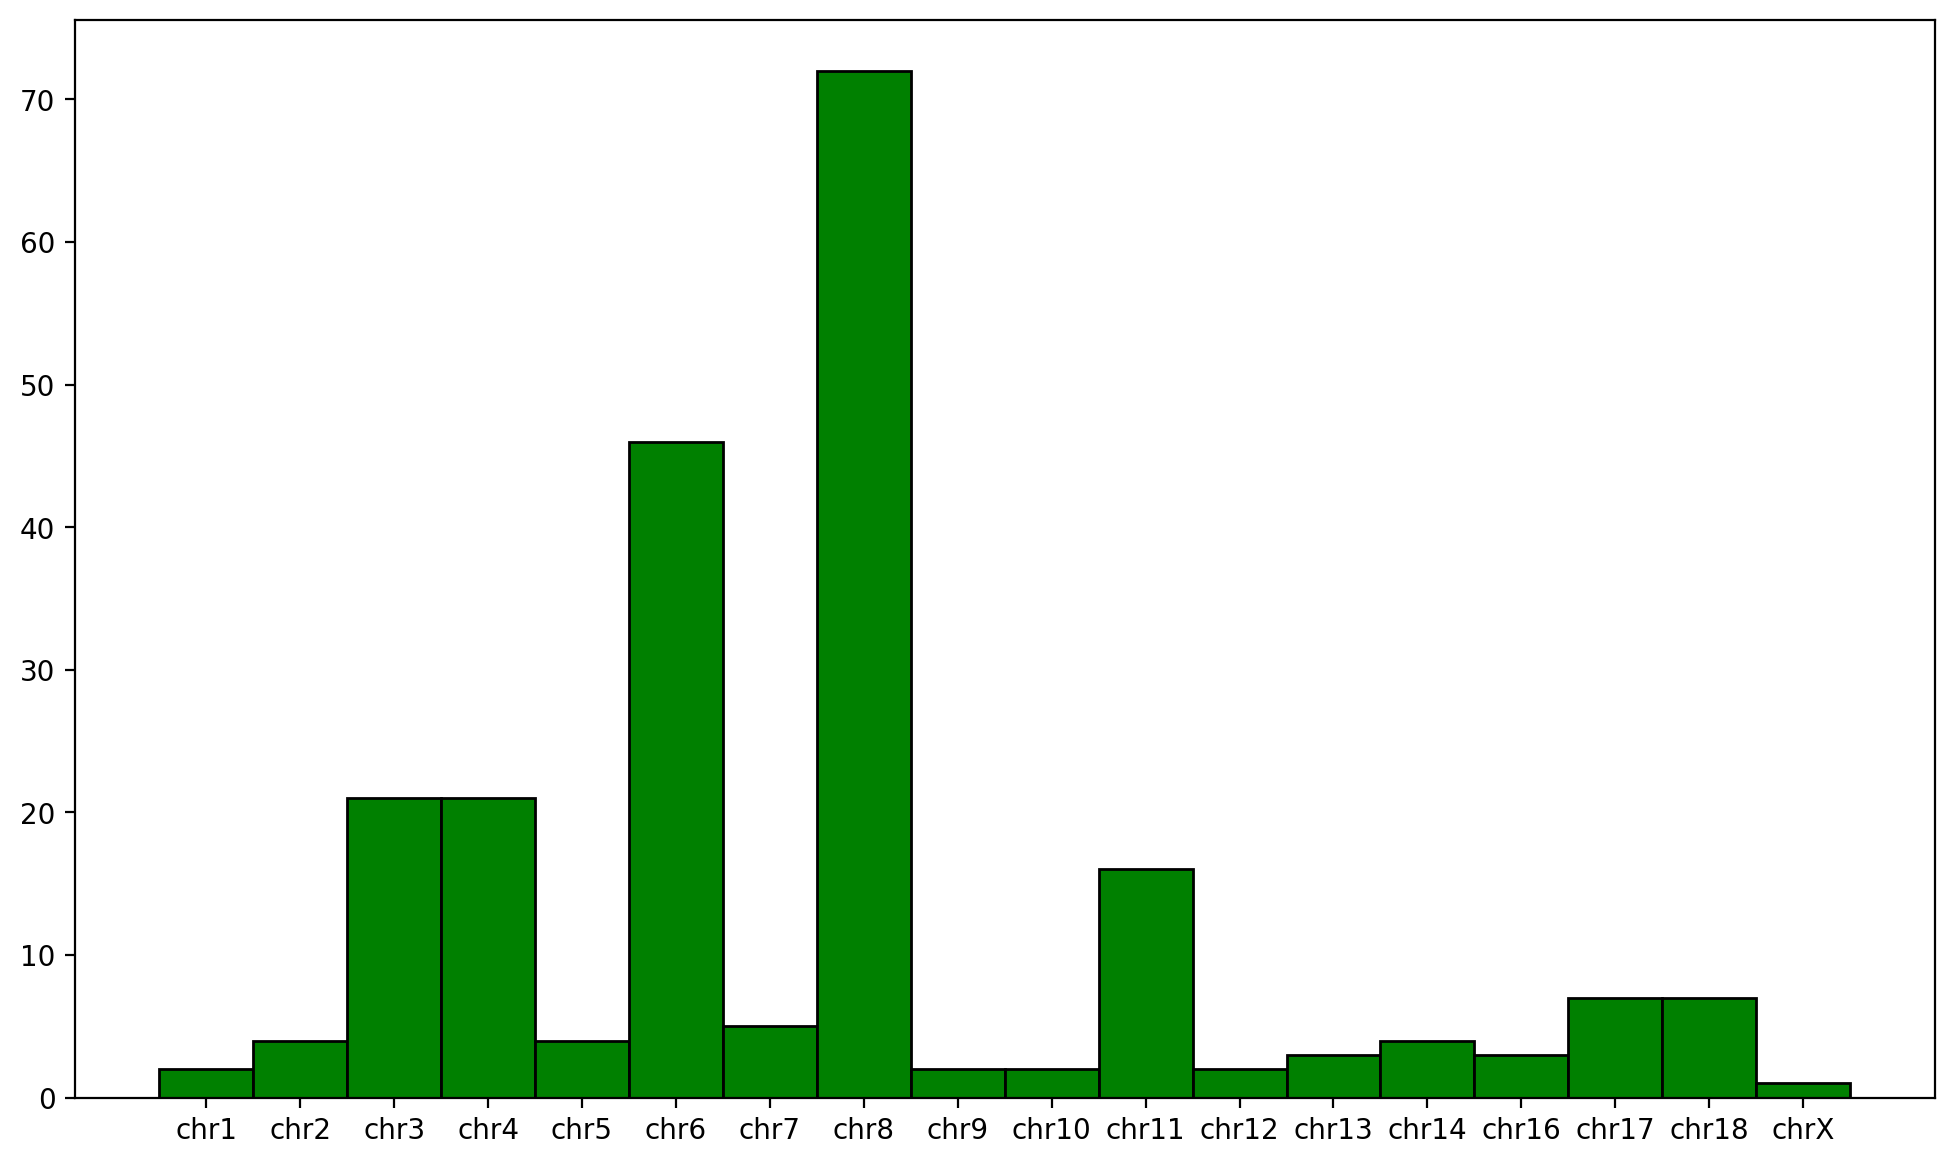

In [7]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 12, 7

pos = len(chr_dict.keys())
width = 1.0

ax = plt.axes()
#ax.set_xticks(18 + (width / 2))
ax.set_xticklabels(chr_dict.keys())

plt.bar(chr_dict.keys(), chr_dict.values(), width, color='g', edgecolor='black',)

plt.show
plt.savefig("core_chr_dist.png", bbox_inches="tight")

In [8]:
print(chr_dict)

{'chr1': 2, 'chr2': 4, 'chr3': 21, 'chr4': 21, 'chr5': 4, 'chr6': 46, 'chr7': 5, 'chr8': 72, 'chr9': 2, 'chr10': 2, 'chr11': 16, 'chr12': 2, 'chr13': 3, 'chr14': 4, 'chr16': 3, 'chr17': 7, 'chr18': 7, 'chrX': 1}


In [9]:
chr_df = pd.DataFrame.from_dict(chr_dict, orient='index')

### Casting CHR_8 to MB 25

In [ ]:
# Read in core incidence
path_chr_8 = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/by_chromosome/population_mESC_1000000_chr8.h5ad"

start_time = time.time()  # Record the start time
adata = sc.read_h5ad(path_chr_8)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()

In [ ]:
adata.obs

In [ ]:
# Ensure X is a proper 2D dense numpy array
if issparse(adata.X):
    X = np.array(adata.X.todense())
else:
    X = np.array(adata.X)

# Confirm it's 2D
print(f"X type: {type(X)}, shape: {X.shape}, ndim: {X.ndim}")

# Parse bin names
parsed = adata.obs.index.to_series().str.extract(r'(chr\w+):(\d+)')
parsed.columns = ['chr', 'pos']
parsed['pos'] = parsed['pos'].astype(int)
parsed['new_bin'] = parsed['chr'] + ':' + (parsed['pos'] // 25).astype(str)

groups = parsed['new_bin'].values

unique_groups = sorted(
    pd.unique(groups),
    key=lambda x: (x.split(':')[0], int(x.split(':')[1]))
)

n_new = len(unique_groups)
X_new = np.zeros((n_new, n_new))

for i, g1 in enumerate(unique_groups):
    mask1 = groups == g1
    for j, g2 in enumerate(unique_groups):
        mask2 = groups == g2
        X_new[i, j] = X[np.ix_(mask1, mask2)].sum()

# Build new AnnData
new_obs = pd.DataFrame(index=unique_groups)
adata_25mb = ad.AnnData(X=X_new, obs=new_obs, var=new_obs.copy())

print(f"Original: {adata.shape}")
print(f"Aggregated: {adata_25mb.shape}")

In [ ]:
# Your aggregated 25Mb contact matrix
X_25mb = adata_25mb.X

# Option 1: Binary — any contact > 0
incidence = (X_25mb > 0).astype(int)

# Option 2: Threshold — contacts above a cutoff
threshold = np.median(X_25mb[X_25mb > 0])  # median of non-zero contacts
incidence = (X_25mb >= threshold).astype(int)

# Option 3: Top percentile
percentile_cutoff = np.percentile(X_25mb, 75)  # top 25% of interactions
incidence = (X_25mb >= percentile_cutoff).astype(int)

print(f"Incidence matrix shape: {incidence.shape}")
print(f"Density: {incidence.sum() / incidence.size:.2%}")

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

axes.imshow(np.log1p(X_25mb), cmap='hot')
axes.set_title("25Mb Contact Counts (log)")

plt.tight_layout()
plt.show()

In [ ]:
# Build graph from incidence matrix
G = nx.Graph()

# Add nodes
for node in unique_groups:
    G.add_node(node)

# Add edges (upper triangle to avoid duplicates, no self-loops)
rows, cols = np.where(np.triu(incidence, k=1) == 1)
for r, c in zip(rows, cols):
    G.add_edge(unique_groups[r], unique_groups[c])

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

# Color nodes by chromosome
chr_labels = [node.split(':')[0] for node in G.nodes()]
unique_chrs = sorted(set(chr_labels))
chr_colormap = plt.cm.tab20(np.linspace(0, 1, len(unique_chrs)))
chr_to_color = {ch: chr_colormap[i] for i, ch in enumerate(unique_chrs)}
node_colors = [chr_to_color[node.split(':')[0]] for node in G.nodes()]

shells = [[n for n in G.nodes() if n.startswith(ch)] for ch in unique_chrs]
pos = nx.shell_layout(G, nlist=shells)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, 
                       node_size=200, edgecolors='black', linewidths=0.5)

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=0.5, edge_color='gray')

nx.draw_networkx_labels(G, pos, ax=ax, font_size=5)

# Legend for chromosomes
for ch, color in chr_to_color.items():
    ax.scatter([], [], c=[color], s=100, label=ch)
ax.legend(loc='upper left', fontsize=8, ncol=2)

ax.set_title("Pore_C Chr8 25 MB Incidence Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Add weighted edges
G_weighted = nx.Graph()

for node in unique_groups:
    G_weighted.add_node(node)

rows, cols = np.where(np.triu(incidence, k=1) == 1)
for r, c in zip(rows, cols):
    weight = X_25mb[r, c]
    G_weighted.add_edge(unique_groups[r], unique_groups[c], weight=weight)

# Scale edge width by contact strength
edges = G_weighted.edges(data=True)
weights = [e[2]['weight'] for e in edges]
max_w = max(weights)
edge_widths = [3 * w / max_w for w in weights]

fig, ax = plt.subplots(figsize=(12, 12))

shells = [[n for n in G.nodes() if n.startswith(ch)] for ch in unique_chrs]
pos = nx.shell_layout(G, nlist=shells)

nx.draw_networkx_nodes(G_weighted, pos, ax=ax, node_color=node_colors,
                       node_size=200, edgecolors='black', linewidths=0.5)

nx.draw_networkx_edges(G_weighted, pos, ax=ax, alpha=0.4,
                       width=edge_widths, edge_color='gray')

nx.draw_networkx_labels(G_weighted, pos, ax=ax, font_size=5)

ax.set_title("Pore_C Chr8 25 MB Incidence Matrix")
plt.tight_layout()
plt.show()

### Casting Cell 03b82 to 25 MB 

In [ ]:
sc_path = f"/scratch/indikar_root/indikar1/jduhamel/pore_c/singlecell_mESC_1000000_features_en.h5ad"

bdata_main = sc.read_h5ad(sc_path)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()

bdata_main.obsm

In [ ]:
bdata = bdata_main.copy()

In [ ]:
cell_id = 'o3b82'


# extract the single-cell
sc_data = bdata[:, bdata.var['basename'] == cell_id].copy()
H_cell = sc_data.to_df()
H_cell = H_cell.T.drop_duplicates().T  # Transpose, drop duplicates, transpose back
H_cell.columns = [f"{cell_id}_{x}" for x in H_cell.columns]


print("Finished processing cells in: ")

In [ ]:
H_cell

In [105]:
H_cell_mod = H_cell.replace(0, pd.NA)

read_dict=H_cell_mod.count()

read_dict = read_dict.to_dict()

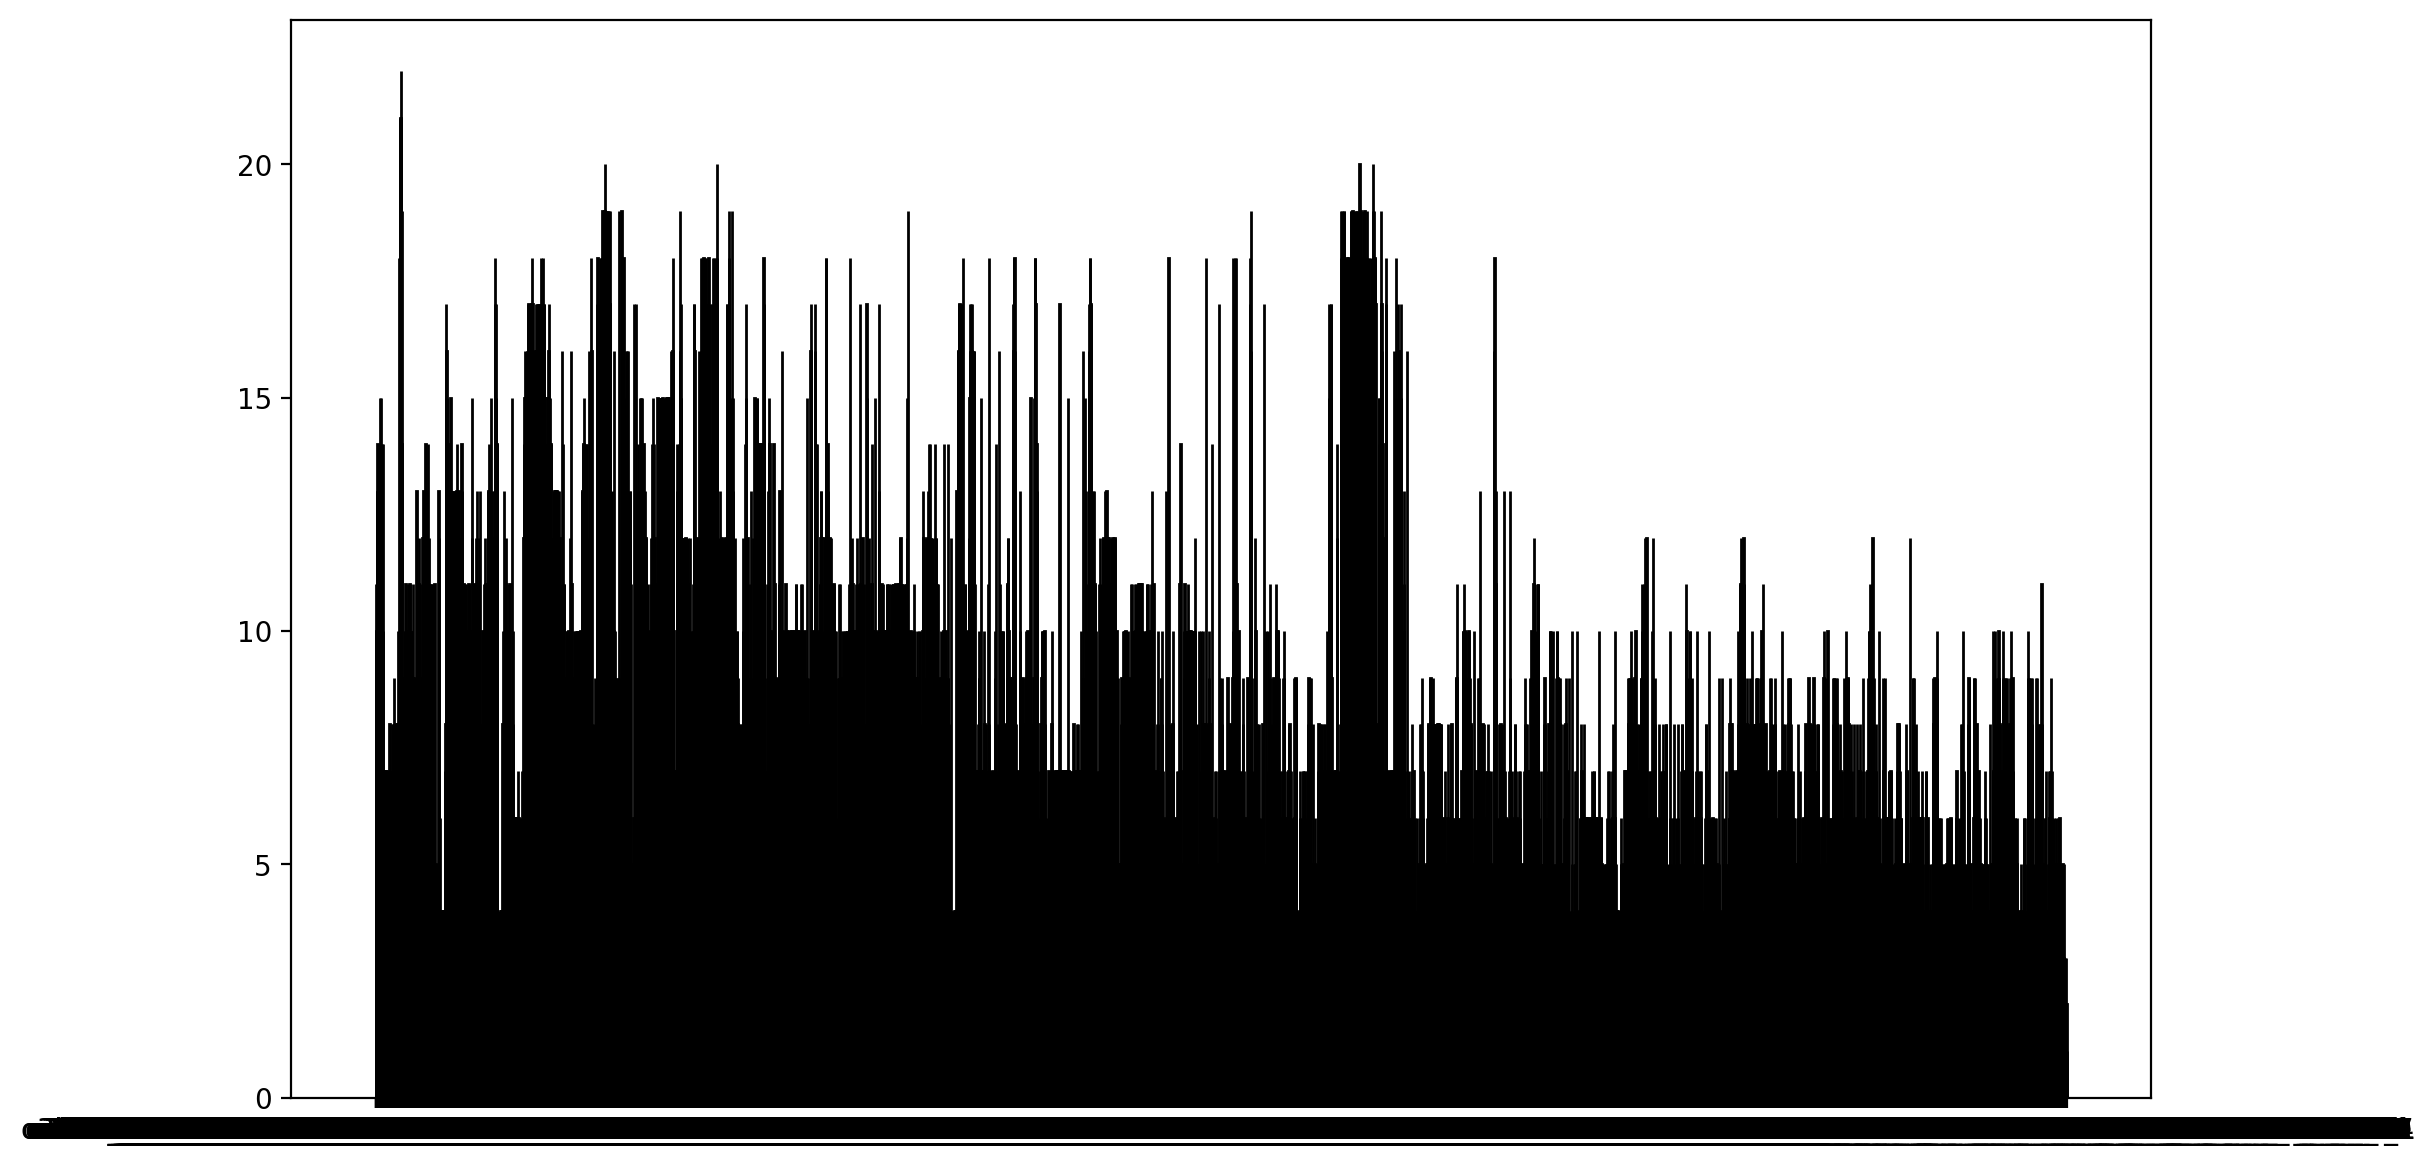

In [106]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 12, 7

pos = len(read_dict.keys())
width = 1.0

ax = plt.axes()
#ax.set_xticks(18 + (width / 2))
ax.set_xticklabels(read_dict.keys())

plt.bar(read_dict.keys(), read_dict.values(), width, color='red', edgecolor='black', )

plt.show
plt.savefig("read_dist.png", bbox_inches="tight")

In [135]:

###MAKING AN ADJACENCY MATRIX

H_cell_array = np.array(H_cell)

parsed = H_cell.index.to_series().str.extract(r'(chr\w+):(\d+)')
parsed.columns = ['chr', 'pos']
parsed['pos'] = parsed['pos'].astype(int)

DIVISOR = 25 

parsed['new_bin'] = (
    parsed['chr'] + ':' +
    (parsed['pos'] // DIVISOR).astype(str)
)

groups = parsed['new_bin'].values

unique_groups = sorted(
    pd.unique(groups),
    key=lambda x: (x.split(':')[0], int(x.split(':')[1]))
)

n_new = len(unique_groups)

print(n_new)
group_to_idx = {g: i for i, g in enumerate(unique_groups)}

H_cell_new = np.zeros((n_new, n_new))

for i, g1 in enumerate(unique_groups):
    mask1 = groups == g1
    for j, g2 in enumerate(unique_groups):
        mask2 = groups == g2
        H_cell_new[i, j] = H_cell_array[np.ix_(mask1, mask2)].sum()

np.fill_diagonal(H_cell_new, 0)


print(len(H_cell_new))

new_H_cell_1 = pd.DataFrame(
    H_cell_new,
    index=unique_groups,
    columns=unique_groups
)


print(f"Original shape:    {H_cell.shape}")
print(f"Aggregated shape:  {new_H_cell_1.shape}")
print(f"Original sum:      {H_cell_array.sum():.4f}")
print(f"Aggregated sum:    {H_cell_new.sum():.4f}")

new_H_cell_1.head() # mask over 2579 rows

114
114
Original shape:    (2579, 9885)
Aggregated shape:  (114, 114)
Original sum:      64104.0000
Aggregated sum:    22096.0000


,chr1:0,chr1:1,chr1:2,chr1:3,chr1:4,chr1:5,chr1:6,chr1:7,chr10:0,chr10:1,...,chr9:2,chr9:3,chr9:4,chrX:0,chrX:1,chrX:2,chrX:3,chrX:4,chrX:5,chrX:6
chr1:0,0.0,2.0,2.0,2.0,6.0,2.0,2.0,1.0,2.0,2.0,...,1.0,1.0,3.0,1.0,2.0,2.0,1.0,1.0,5.0,1.0
chr1:1,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,0.0
chr1:2,4.0,1.0,0.0,2.0,2.0,6.0,6.0,5.0,1.0,2.0,...,0.0,0.0,3.0,0.0,2.0,1.0,2.0,2.0,3.0,3.0
chr1:3,1.0,3.0,1.0,0.0,0.0,5.0,0.0,0.0,2.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,2.0,2.0,0.0,0.0
chr1:4,4.0,4.0,1.0,4.0,0.0,6.0,3.0,4.0,4.0,3.0,...,1.0,4.0,1.0,3.0,2.0,4.0,3.0,3.0,1.0,3.0


chr1:0    72
chr1:1    87
chr1:2    82
chr1:3    84
chr1:4    92
          ..
chrX:2    78
chrX:3    69
chrX:4    86
chrX:5    82
chrX:6    65
Length: 114, dtype: int64


In [138]:
H_cell_array = np.array(H_cell)

# --- Parse row bins only ---
parsed = H_cell.index.to_series().str.extract(r'(chr\w+):(\d+)')
parsed.columns = ['chr', 'pos']
parsed['pos'] = parsed['pos'].astype(int)

positions = parsed['pos'].to_list()

bin_master =  {}

for i in range(len(positions)):
    if (postitions[i]//5) not in bin_master.keys():
        bin_master[postitions[i]//5] = postitions[i]
    elif (postitions[i]//5) in bin_master.keys():
        bin_master[postitions[i]//5]].append(positions[i])

print(bin_master)


DIVISOR = 25

parsed['new_bin'] = (
    parsed['chr'] + ':' +
    (parsed['pos'] // DIVISOR).astype(str)
)

row_groups = parsed['new_bin'].values  

print(row_groups)

new_IM = {}
new_IM.key() = row_groups




unique_row_bins = sorted(
    pd.unique(row_groups),
    key=lambda x: (x.split(':')[0], int(x.split(':')[1]))
)

n_new_rows = len(unique_row_bins)
print(f"Original rows:    {H_cell.shape[0]}")
print(f"Aggregated rows:  {n_new_rows}")
print(f"Columns (reads):  {H_cell.shape[1]}  (unchanged)")


H_cell_new = np.zeros((n_new_rows, H_cell.shape[1]))

for i, g in enumerate(unique_row_bins):
    mask = row_groups == g                   
    H_cell_new[i, :] = H_cell_array[mask, :].sum(axis=0) 

np.fill_diagonal(H_cell_new, 0)

new_H_cell = pd.DataFrame(
    H_cell_new,
    index=unique_row_bins,
    columns=H_cell.columns
)


print(f"\nOriginal shape:    {H_cell.shape}")
print(f"Aggregated shape:  {new_H_cell.shape}")
print(f"Original sum:      {H_cell_array.sum():.4f}")
print(f"Aggregated sum:    {H_cell_new.sum():.4f}")

Original rows:    2579
Aggregated rows:  114
Columns (reads):  9885  (unchanged)

Original shape:    (2579, 9885)
Aggregated shape:  (114, 9885)
Original sum:      64104.0000
Aggregated sum:    64095.0000


In [140]:
H_cell_new_mod = new_H_cell.replace(0, pd.NA)

read_dict_new =H_cell_new_mod.count(axis='rows')

read_dict_new = read_dict_new.to_dict()

o3b82_ea44bd58-3f19-5a79-88fa-983545deeb9b      11
o3b82_9ff53864-f712-4cc6-ac30-3f70d3a48f1e      10
o3b82_88a250c0-9c9c-4ad6-81a9-1e1fdfd4c4a2_2    10
o3b82_a35e4e06-240f-460f-ac24-7913ff729eea      10
o3b82_ed71a1da-ecea-4b03-ab76-4daf5314a29e      10
                                                ..
o3b82_7d4215bd-2514-41d5-97df-888d7ba4c787       2
o3b82_f864f28e-ed91-4b72-ab6c-fb1757d87e84       3
o3b82_3be61cf1-4f1e-46b7-97cf-84eb2a41a6a9       2
o3b82_aeed7255-0fdb-4401-92e7-447ae3fa046f       2
o3b82_3eebd096-9bac-4df9-910f-e54adab73c96       1
Length: 9885, dtype: int64


In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 12, 7

pos = len(read_dict_new.keys())
width = 1.0

ax = plt.axes()
#ax.set_xticks(18 + (width / 2))
ax.set_xticklabels(read_dict_new.keys())

plt.bar(read_dict_new.keys(), read_dict_new.values(), width, color='g', edgecolor='black',)

plt.show
plt.savefig("read_dist.png", bbox_inches="tight")

In [57]:
def genomic_incidence_plot(
    incidence_df,
    shade_rows=True,
    connect_nodes=True,
    dpi=200,
    edge_colors=None,
    node_labels=True,
    figsize=(16, 8)
):

    plt.rcParams['figure.dpi'] = dpi

    matrix = incidence_df.values
    n, m = matrix.shape  # n = genomic bins (rows), m = reads (cols)
    m = 100

    fig, ax = plt.subplots(figsize=figsize)

    if edge_colors is None:
        edge_colors = plt.cm.tab20(np.linspace(0, 1, m))

    for i in range(m):
        y_pts = np.where(matrix[:, i] != 0)[0]
        if len(y_pts) == 0:
            continue

        x_pts = i * np.ones(len(y_pts))

        ax.scatter(
            x_pts, y_pts,
            color=edge_colors[i],
            edgecolor='k',
            linewidths=0.3,
            s=10,
            zorder=2
        )

        if connect_nodes and len(y_pts) > 1:
            ax.plot(
                [i, i],
                [y_pts.min(), y_pts.max()],
                c='k',
                lw=0.8,
                zorder=1
            )

    if shade_rows:
        for row in range(0, n, 2):   # every other row
            ax.barh(
                row,
                m - 0.5,             # full width
                height=1.0,
                color='grey',
                left=-0.25,
                alpha=0.3,
                zorder=0
            )

    ax.set_xlim([-0.5, m - 0.5])
    ax.set_ylim([-0.5, n - 0.5])

    if node_labels:
        ax.set_yticks(range(n))
        ax.set_yticklabels(incidence_df.index.tolist(), fontsize=7)
    else:
        ax.set_yticks([])

    ax.set_xticks([])
    ax.set_xlabel('Reads', fontsize=10)
    ax.set_ylabel('Genomic Bin (25 Mb)', fontsize=10)
    ax.set_title('Genomic Contact Incidence Matrix', fontsize=12)

    plt.tight_layout()
    return ax

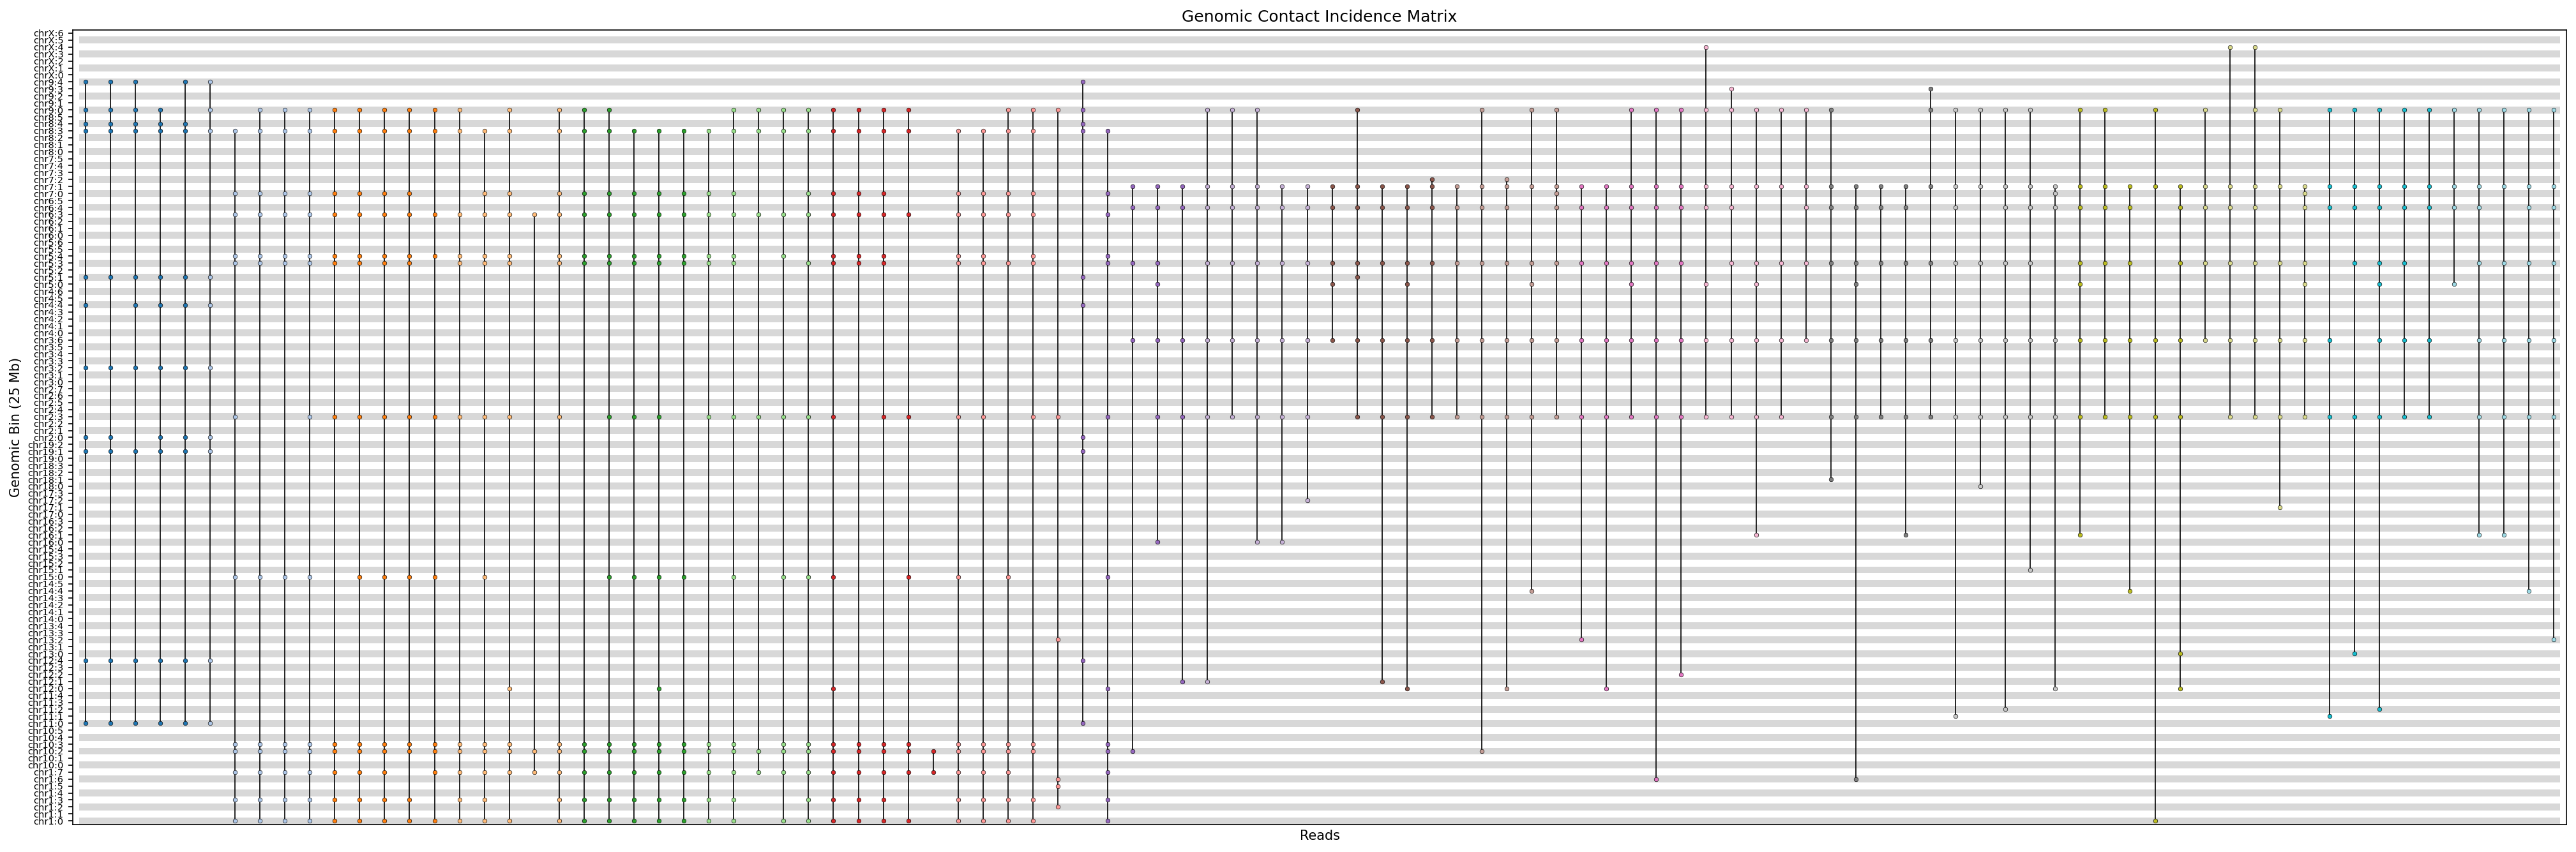

In [58]:
ax = genomic_incidence_plot(
    new_H_cell,
    shade_rows=True,
    connect_nodes=True,
    dpi=150,
    node_labels=True,
    figsize=(27, 9)
)
plt.show()

In [37]:
def plot_contact_matrix(
    incidence_df,
    log_transform=True,
    cmap='Reds',
    dpi=200,
    figsize=(10, 8),
    title='Genomic Contact Matrix (25 Mb bins)'
):

    plt.rcParams['figure.dpi'] = dpi

    # --- Compute bin x bin contact matrix ---
    H = incidence_df.values.astype(float)
    contact_matrix = H @ H.T  # shape: (n_bins, n_bins)

    # --- Optional log transform ---
    if log_transform:
        plot_data = np.log1p(contact_matrix)
        cbar_label = 'log(1 + shared reads)'
    else:
        plot_data = contact_matrix
        cbar_label = 'Shared reads'

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        plot_data,
        ax=ax,
        cmap=cmap,
        square=True,                        # keep cells square like a Hi-C map,
        cbar_kws={'label': cbar_label, 'shrink': 0.8},
        linewidths=0.3,
        linecolor='white'
    )

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha='right',
        fontsize=7
    )
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=7
    )

    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel('Genomic Bin', fontsize=10)
    ax.set_ylabel('Genomic Bin', fontsize=10)

    plt.tight_layout()
    return ax, contact_matrix   # return raw matrix for further analysis

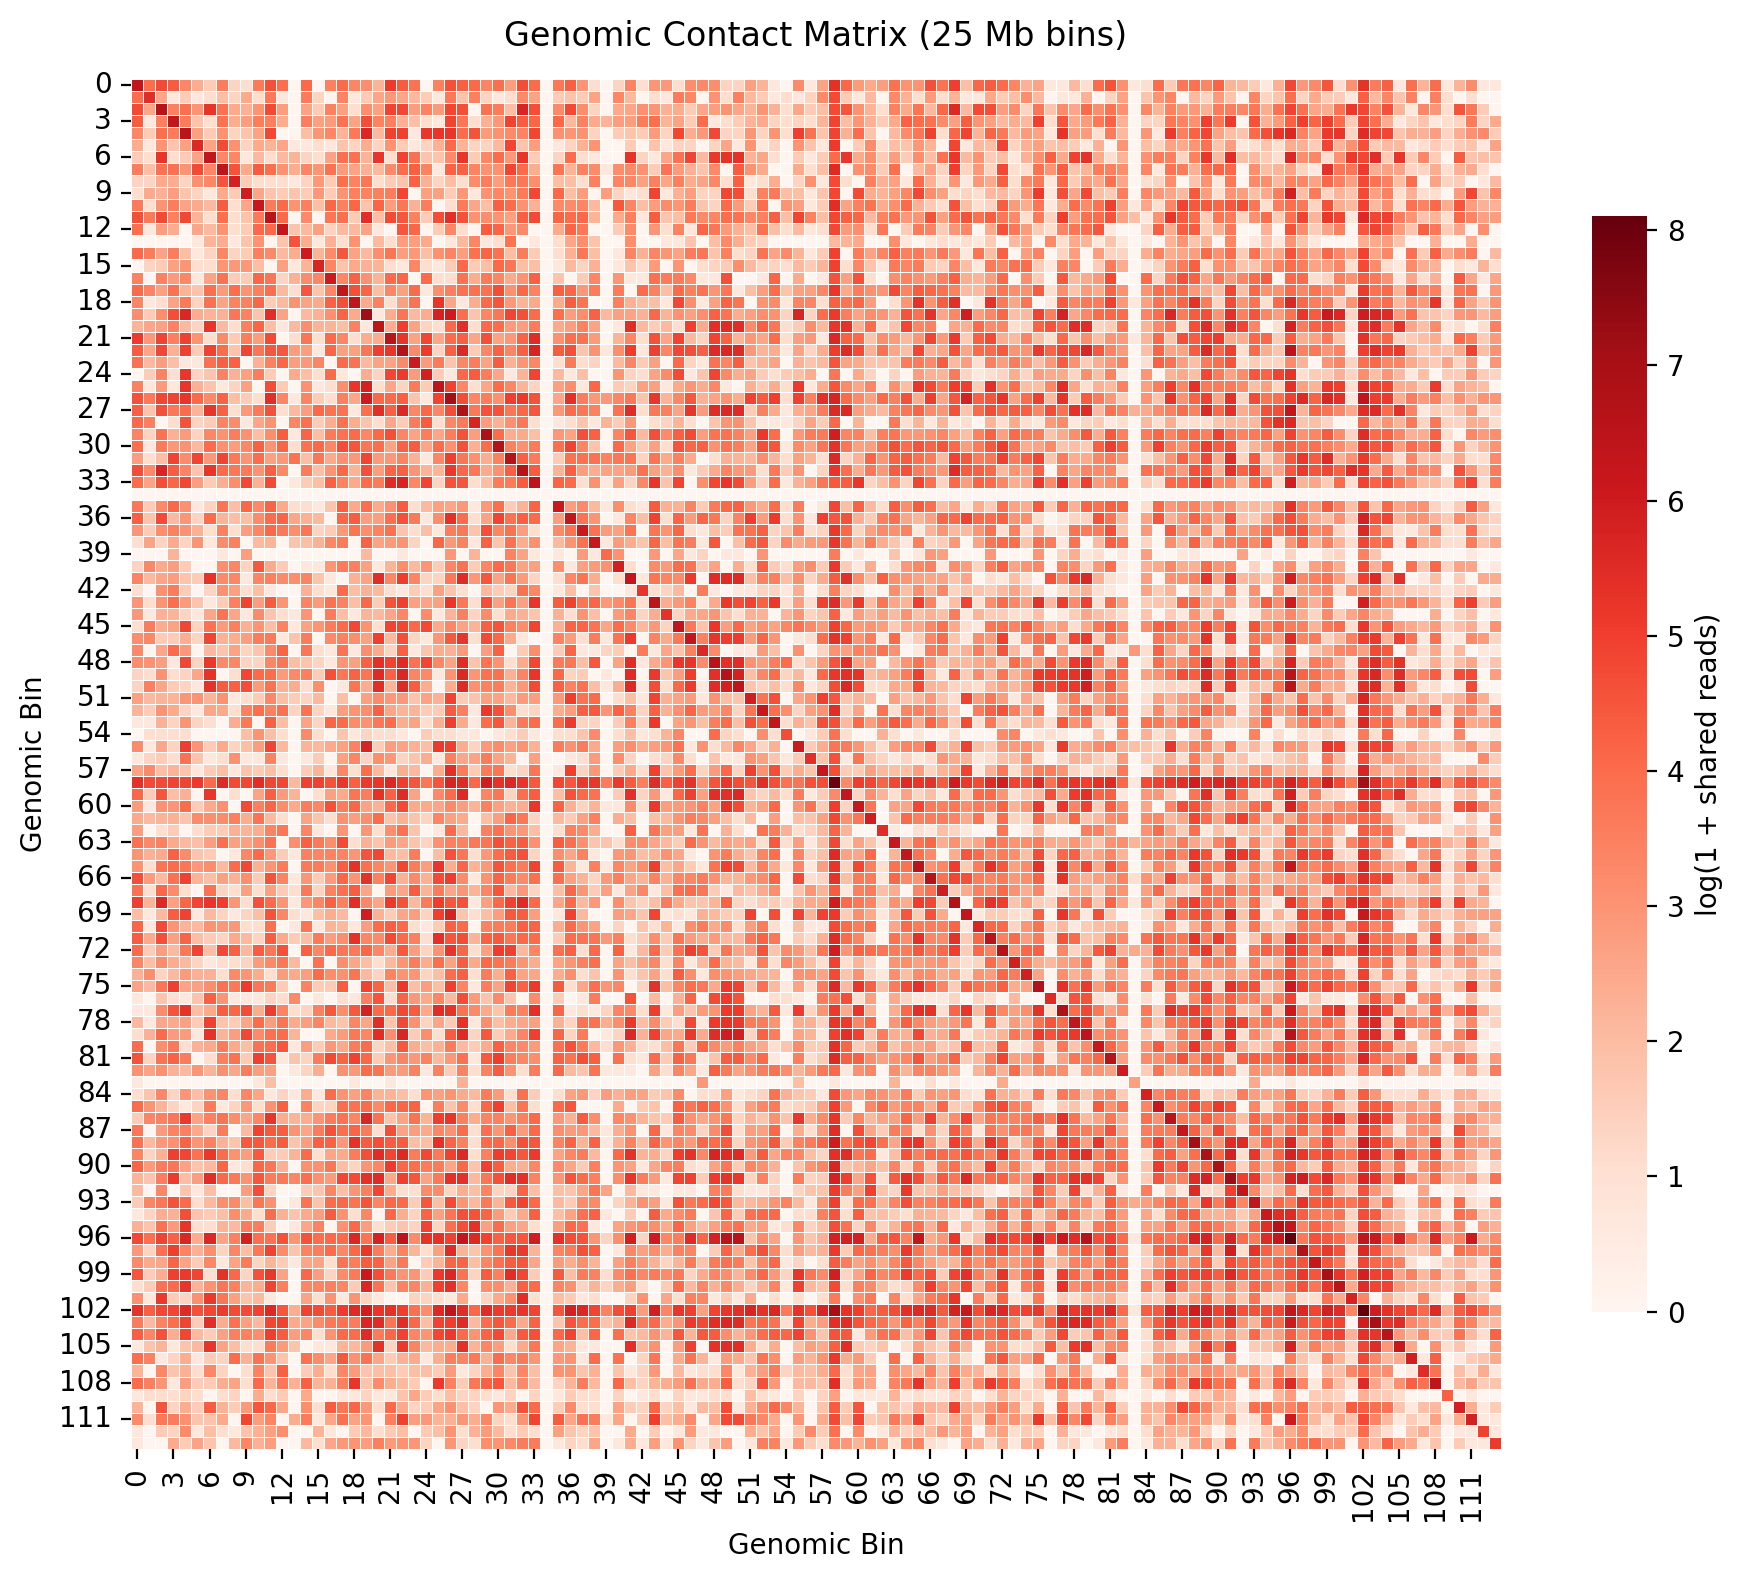

In [38]:
ax, contact_matrix = plot_contact_matrix(
    new_H_cell,
    log_transform=True,
    cmap='Reds',
    figsize=(10, 8)
)
plt.show()